# FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V4.csv
# >
# FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv

In [13]:
import pandas as pd
from pathlib import Path
import time
import gc

# ==================================================
# FILE - V4 ONLY
# ==================================================

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V4.csv")
chunksize = 200_000

# ==================================================
# SAFE DISPLAY FUNCTION
# Works in Jupyter, and also will not crash in normal Python
# ==================================================

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

# ==================================================
# CHECK FILE
# ==================================================

print("Checking file...")
print("File:", file)
print("File exists:", file.exists())

if not file.exists():
    raise FileNotFoundError(f"Cannot find file: {file}")

size_gb = file.stat().st_size / (1024 ** 3)
print(f"File size: {size_gb:.2f} GB")

# ==================================================
# DISPLAY SETTINGS
# ==================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 300)
pd.set_option("display.max_colwidth", 120)

# ==================================================
# MEMORY SAFE PREVIEW
# Only loads first 20 rows
# ==================================================

print("\n==============================")
print("TOP 20 ROWS FROM V4")
print("==============================")

df_preview = pd.read_csv(
    file,
    nrows=20,
    low_memory=False,
    keep_default_na=False,
    dtype=str
)

print("Rows loaded:", len(df_preview))
print("Columns found:", len(df_preview.columns))

print("\n==============================")
print("COLUMN NAMES")
print("==============================")

for i, col in enumerate(df_preview.columns, start=1):
    print(f"{i}. {col}")

print("\n==============================")
print("TOP 20 ROWS")
print("==============================")

display(df_preview)

print("\n==============================")
print("TOP 20 ROWS TRANSPOSED")
print("Better view if many columns")
print("==============================")

display(df_preview.T)

# ==================================================
# CHECK REQUIRED COLUMNS
# ==================================================

required_cols = ["field_group", "field_subgroup", "major_name"]

missing_cols = [col for col in required_cols if col not in df_preview.columns]

if missing_cols:
    print("\nAvailable columns:")
    print(list(df_preview.columns))
    raise ValueError(f"Missing required columns: {missing_cols}")

del df_preview
gc.collect()

# ==================================================
# MEMORY OPTIMIZED FULL FILE CHECK
# Important:
# usecols loads ONLY these 3 columns from the big CSV
# This saves memory
# ==================================================

print("\n==============================")
print("CHECKING V4 FILE IN CHUNKS")
print("==============================")

start = time.time()

total_rows = 0

unknown_group = 0
unknown_subgroup = 0
unknown_major = 0

unmapped_group = 0
unmapped_subgroup = 0
unmapped_major = 0

blank_group = 0
blank_subgroup = 0
blank_major = 0

bad_major_examples = []

reader = pd.read_csv(
    file,
    usecols=required_cols,        # memory optimization: read only needed columns
    chunksize=chunksize,          # memory optimization: read piece by piece
    low_memory=False,
    keep_default_na=False,
    dtype=str
)

for chunk_num, chunk in enumerate(reader, start=1):

    total_rows += len(chunk)

    field_group = chunk["field_group"].str.strip()
    field_subgroup = chunk["field_subgroup"].str.strip()
    major_name = chunk["major_name"].str.strip()

    # ==================================================
    # BAD UNKNOWN LABELS
    # ==================================================

    unknown_group_mask = field_group.str.contains(
        "Unknown Field Group",
        case=False,
        na=False
    )

    unknown_subgroup_mask = field_subgroup.str.contains(
        "Unknown Subgroup",
        case=False,
        na=False
    )

    unknown_major_mask = major_name.str.contains(
        "Unknown Major",
        case=False,
        na=False
    )

    unknown_group += int(unknown_group_mask.sum())
    unknown_subgroup += int(unknown_subgroup_mask.sum())
    unknown_major += int(unknown_major_mask.sum())

    # Save small example only, not full data
    if unknown_major_mask.any() and len(bad_major_examples) < 5:
        bad_major_examples.append(chunk.loc[unknown_major_mask].head(5))

    # ==================================================
    # TRANSPARENT NONSTANDARD LABELS
    # ==================================================

    unmapped_group += int(
        field_group.str.contains(
            "Unmapped Field Group",
            case=False,
            na=False
        ).sum()
    )

    unmapped_subgroup += int(
        field_subgroup.str.contains(
            "Unmapped Subgroup",
            case=False,
            na=False
        ).sum()
    )

    unmapped_major += int(
        major_name.str.contains(
            "Unmapped Major",
            case=False,
            na=False
        ).sum()
    )

    # ==================================================
    # BLANK LABELS
    # ==================================================

    blank_group += int(field_group.eq("").sum())
    blank_subgroup += int(field_subgroup.eq("").sum())
    blank_major += int(major_name.eq("").sum())

    # ==================================================
    # PROGRESS
    # ==================================================

    elapsed = time.time() - start
    rows_per_sec = total_rows / elapsed if elapsed > 0 else 0

    print(
        f"\rChunk: {chunk_num:,} | "
        f"Rows checked: {total_rows:,} | "
        f"Speed: {rows_per_sec:,.0f} rows/sec | "
        f"Unknown major so far: {unknown_major:,}",
        end=""
    )

    del chunk
    gc.collect()

# ==================================================
# FINAL REPORT
# ==================================================

print("\n\nDONE")
print(f"Total rows checked: {total_rows:,}")

print("\nBad unknown labels:")
print(f"Unknown field group rows: {unknown_group:,}")
print(f"Unknown subgroup rows: {unknown_subgroup:,}")
print(f"Unknown major rows: {unknown_major:,}")

print("\nTransparent nonstandard labels:")
print(f"Unmapped field group rows: {unmapped_group:,}")
print(f"Unmapped subgroup rows: {unmapped_subgroup:,}")
print(f"Unmapped major rows: {unmapped_major:,}")

print("\nBlank labels:")
print(f"Blank field group rows: {blank_group:,}")
print(f"Blank subgroup rows: {blank_subgroup:,}")
print(f"Blank major rows: {blank_major:,}")

# ==================================================
# SHOW SAMPLE UNKNOWN MAJOR ROWS ONLY IF FOUND
# ==================================================

if bad_major_examples:
    print("\n==============================")
    print("SAMPLE UNKNOWN MAJOR ROWS")
    print("==============================")

    bad_sample = pd.concat(bad_major_examples, ignore_index=True)
    display(bad_sample)

else:
    print("\nNo Unknown Major rows found.")

Checking file...
File: FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V4.csv
File exists: True
File size: 3.71 GB

TOP 20 ROWS FROM V4
Rows loaded: 20
Columns found: 242

COLUMN NAMES
1. unitid
2. cipcode
3. awlevel
4. crace15
5. crace16
6. part
7. crace01
8. crace02
9. crace03
10. crace04
11. crace05
12. crace06
13. crace07
14. crace08
15. crace09
16. crace10
17. crace11
18. crace12
19. crace13
20. crace14
21. bal_m
22. bal_w
23. imprac01
24. imprac02
25. imprac03
26. imprac04
27. imprac05
28. imprac06
29. imprac07
30. imprac08
31. imprac09
32. imprac10
33. imprac11
34. imprac12
35. imprac13
36. imprac14
37. imprac15
38. imprac16
39. ix01
40. ix02
41. ix03
42. ix04
43. ix05
44. ix06
45. ix07
46. ix08
47. ix09
48. ix10
49. ix11
50. ix12
51. ix13
52. ix14
53. ix15
54. ix16
55. cbalm
56. cbalw
57. xcrace01
58. xcrace02
59. xcrace03
60. xcrace04
61. xcrace05
62. xcrace06
63. xcrace07
64. xcrace08
65. xcrace09
66. xcrace10
67. xcrace11
68. xcrace12
69. xcrace13
70. xcrace14
71. xcrace15
72. xcr

,unitid,cipcode,awlevel,crace15,crace16,part,crace01,crace02,crace03,crace04,crace05,crace06,crace07,crace08,crace09,crace10,crace11,crace12,crace13,crace14,bal_m,bal_w,imprac01,imprac02,imprac03,imprac04,imprac05,imprac06,imprac07,imprac08,imprac09,imprac10,imprac11,imprac12,imprac13,imprac14,imprac15,imprac16,ix01,ix02,ix03,ix04,ix05,ix06,ix07,ix08,ix09,ix10,ix11,ix12,ix13,ix14,ix15,ix16,cbalm,cbalw,xcrace01,xcrace02,xcrace03,xcrace04,xcrace05,xcrace06,xcrace07,xcrace08,xcrace09,xcrace10,xcrace11,xcrace12,xcrace13,xcrace14,xcrace15,xcrace16,xcrace17,crace17,xcrace18,crace18,xcrace19,crace19,xcrace20,crace20,xcrace21,crace21,xcrace22,crace22,xcrace23,crace23,xcrace24,crace24,majornum,UNITID,CIPCODE,AWLEVEL,MAJORNUM,XCRACE01,CRACE01,XCRACE02,CRACE02,XCRACE03,CRACE03,XCRACE04,CRACE04,XCRACE05,CRACE05,XCRACE06,CRACE06,XCRACE07,CRACE07,XCRACE08,CRACE08,XCRACE09,CRACE09,XCRACE10,CRACE10,XCRACE11,CRACE11,XCRACE12,CRACE12,XCRACE13,CRACE13,XCRACE14,CRACE14,XCRACE15,CRACE15,XCRACE16,CRACE16,XCRACE17,CRACE17,XCRACE18,CRACE18,XCRACE19,CRACE19,XCRACE20,CRACE20,XCRACE21,CRACE21,XCRACE22,CRACE22,XCRACE23,CRACE23,XCRACE24,CRACE24,XCNRALM,CNRALM,XCNRALW,CNRALW,XCUNKNM,CUNKNM,XCUNKNW,CUNKNW,XCTOTALM,CTOTALM,XCTOTALW,CTOTALW,XCNRALT,CNRALT,XCUNKNT,CUNKNT,XCTOTALT,CTOTALT,XCHISPM,CHISPM,XCHISPW,CHISPW,XCAIANM,CAIANM,XCAIANW,CAIANW,XCASIAM,CASIAM,XCASIAW,CASIAW,XCBKAAM,CBKAAM,XCBKAAW,CBKAAW,XCNHPIM,CNHPIM,XCNHPIW,CNHPIW,XCWHITM,CWHITM,XCWHITW,CWHITW,XC2MORM,C2MORM,XC2MORW,C2MORW,XCHISPT,CHISPT,XCAIANT,CAIANT,XCASIAT,CASIAT,XCBKAAT,CBKAAT,XCNHPIT,CNHPIT,XCWHITT,CWHITT,XC2MORT,C2MORT,XDVCAIT,DVCAIT,XDVCAIM,DVCAIM,XDVCAIW,DVCAIW,XDVCAPT,DVCAPT,XDVCAPM,DVCAPM,XDVCAPW,DVCAPW,XDVCBKT,DVCBKT,XDVCBKM,DVCBKM,XDVCBKW,DVCBKW,XDVCHST,DVCHST,XDVCHSM,DVCHSM,XDVCHSW,DVCHSW,XDVCWHT,DVCWHT,XDVCWHM,DVCWHM,XDVCWHW,DVCWHW,CNRALW,CDISTEDP,year,award_level_code,award_level_name,degree_group,cip_code,degree_count,field_group,field_subgroup,major_name
0,100654,10102,5,11,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,5,Bachelor,Bachelor,10102,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10102),Unknown Major
1,100654,10102,7,14,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,7,Master,Master,10102,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10102),Unknown Major
2,100654,10103,5,1,1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,5,Bachelor,Bachelor,10103,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10103),Unknown Major
3,100654,20201,5,3,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,5,Bachelor,Bachelor,20201,0,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20201),Unknown Major
4,100654,20301,5,3,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,5,Bachelor,Bachelor,20301,0,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20301),Unknown Major
5,100654,20399,7,11,3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


TOP 20 ROWS TRANSPOSED
Better view if many columns


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
unitid,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654,100654
cipcode,10102,10102,10103,20201,20301,20399,20501,29999,29999,30499,40301,40301,60101,60201,60301,60401,60401,60501,60501,61401
awlevel,5,7,5,5,5,7,5,5,7,5,5,7,5,5,5,5,7,5,7,5
crace15,11,14,1,3,3,11,2,1,10,2,7,10,8,17,5,17,91,14,11,22
crace16,0,0,1,0,0,3,0,0,0,0,2,0,12,14,2,22,16,3,1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cip_code,10102,10102,10103,20201,20301,20399,20501,29999,29999,30499,40301,40301,60101,60201,60301,60401,60401,60501,60501,61401
degree_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
field_group,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Field (20),MILITARY TECHNOLOGIES AND APPLIED SCIENCES,MILITARY TECHNOLOGIES AND APPLIED SCIENCES,MULTI/INTERDISCIPLINARY STUDIES,PHYSICAL SCIENCES,PHYSICAL SCIENCES,HEALTH PROFESSIONS RESIDENCY/FELLOWSHIP PROGRAMS,HEALTH PROFESSIONS RESIDENCY/FELLOWSHIP PROGRAMS,HEALTH PROFESSIONS RESIDENCY/FELLOWSHIP PROGRAMS,HEALTH PROFESSIONS RESIDENCY/FELLOWSHIP PROGRAMS,HEALTH PROFESSIONS RESIDENCY/FELLOWSHIP PROGRAMS,HEALTH PROFESSIONS RESIDENCY/FELLOWSHIP PROGRAMS,HEALTH PROFESSIONS RESIDENCY/FELLOWSHIP PROGRAMS,MEDICAL RESIDENCY/FELLOWSHIP PROGRAMS
field_subgroup,Unmapped / Nonstandard CIP Subgroup (10102),Unmapped / Nonstandard CIP Subgroup (10102),Unmapped / Nonstandard CIP Subgroup (10103),Unmapped / Nonstandard CIP Subgroup (20201),Unmapped / Nonstandard CIP Subgroup (20301),Unmapped / Nonstandard CIP Subgroup (20399),Unmapped / Nonstandard CIP Subgroup (20501),Unmapped / Nonstandard CIP Subgroup (29999),Unmapped / Nonstandard CIP Subgroup (29999),Unmapped / Nonstandard CIP Subgroup (30499),Unmapped / Nonstandard CIP Subgroup (40301),Unmapped / Nonstandard CIP Subgroup (40301),Unmapped / Nonstandard CIP Subgroup (60101),Unmapped / Nonstandard CIP Subgroup (60201),Unmapped / Nonstandard CIP Subgroup (60301),Unmapped / Nonstandard CIP Subgroup (60401),Unmapped / Nonstandard CIP Subgroup (60401),Unmapped / Nonstandard CIP Subgroup (60501),Unmapped / Nonstandard CIP Subgroup (60501),Unmapped / Nonstandard CIP Subgroup (61401)



CHECKING V4 FILE IN CHUNKS
Chunk: 45 | Rows checked: 8,830,649 | Speed: 225,378 rows/sec | Unknown major so far: 2,827,644

DONE
Total rows checked: 8,830,649

Bad unknown labels:
Unknown field group rows: 0
Unknown subgroup rows: 0
Unknown major rows: 2,827,644

Transparent nonstandard labels:
Unmapped field group rows: 0
Unmapped subgroup rows: 0
Unmapped major rows: 0

Blank labels:
Blank field group rows: 0
Blank subgroup rows: 0
Blank major rows: 0

SAMPLE UNKNOWN MAJOR ROWS


,field_group,field_subgroup,major_name
0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10102),Unknown Major
1,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10102),Unknown Major
2,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10103),Unknown Major
3,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20201),Unknown Major
4,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20301),Unknown Major
5,THEOLOGY AND RELIGIOUS VOCATIONS,Religious Music and Worship,Unknown Major
6,THEOLOGY AND RELIGIOUS VOCATIONS,Religious Music and Worship,Unknown Major
7,THEOLOGY AND RELIGIOUS VOCATIONS,Theological and Ministerial Studies,Unknown Major
8,THEOLOGY AND RELIGIOUS VOCATIONS,Theological and Ministerial Studies,Unknown Major
9,THEOLOGY AND RELIGIOUS VOCATIONS,Theological and Ministerial Studies,Unknown Major


In [15]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V4.csv")

use_cols = ["field_group", "field_subgroup", "major_name"]

total = 0

bad_unknown_group = 0
bad_unknown_subgroup = 0
bad_unknown_major = 0

unmapped_group = 0
unmapped_subgroup = 0
unmapped_major = 0

blank_group = 0
blank_subgroup = 0
blank_major = 0

sample_unknown_major = []

for chunk in pd.read_csv(
    file,
    usecols=use_cols,
    chunksize=200_000,
    dtype="string",
    keep_default_na=False,
    low_memory=False
):
    total += len(chunk)

    fg = chunk["field_group"].str.strip()
    fs = chunk["field_subgroup"].str.strip()
    mj = chunk["major_name"].str.strip()

    # Bad unknown labels
    bad_unknown_group += fg.eq("Unknown Field Group").sum()
    bad_unknown_subgroup += fs.eq("Unknown Subgroup").sum()
    bad_unknown_major += mj.eq("Unknown Major").sum()

    # Correct transparent nonstandard labels
    unmapped_group += fg.str.startswith("Unmapped / Nonstandard CIP Field").sum()
    unmapped_subgroup += fs.str.startswith("Unmapped / Nonstandard CIP Subgroup").sum()
    unmapped_major += mj.str.startswith("Unmapped / Nonstandard CIP Major").sum()

    # Blank labels
    blank_group += fg.eq("").sum()
    blank_subgroup += fs.eq("").sum()
    blank_major += mj.eq("").sum()

    # Sample Unknown Major rows
    if len(sample_unknown_major) < 25:
        sample = chunk.loc[mj.eq("Unknown Major"), use_cols].head(25 - len(sample_unknown_major))
        if not sample.empty:
            sample_unknown_major.append(sample)

print("DONE")
print(f"Total rows checked: {total:,}")

print("\nBad unknown labels:")
print(f"Unknown field group rows: {bad_unknown_group:,}")
print(f"Unknown subgroup rows: {bad_unknown_subgroup:,}")
print(f"Unknown major rows: {bad_unknown_major:,}")

print("\nTransparent nonstandard labels:")
print(f"Unmapped field group rows: {unmapped_group:,}")
print(f"Unmapped subgroup rows: {unmapped_subgroup:,}")
print(f"Unmapped major rows: {unmapped_major:,}")

print("\nBlank labels:")
print(f"Blank field group rows: {blank_group:,}")
print(f"Blank subgroup rows: {blank_subgroup:,}")
print(f"Blank major rows: {blank_major:,}")

if sample_unknown_major:
    print("\n==============================")
    print("SAMPLE UNKNOWN MAJOR ROWS")
    print("==============================")
    print(pd.concat(sample_unknown_major, ignore_index=True))
else:
    print("\nNo Unknown Major rows found.")

DONE
Total rows checked: 8,830,649

Bad unknown labels:
Unknown field group rows: 0
Unknown subgroup rows: 0
Unknown major rows: 2,827,644

Transparent nonstandard labels:
Unmapped field group rows: 277,945
Unmapped subgroup rows: 451,862
Unmapped major rows: 0

Blank labels:
Blank field group rows: 0
Blank subgroup rows: 0
Blank major rows: 0

SAMPLE UNKNOWN MAJOR ROWS
                                                      field_group                               field_subgroup     major_name
0    COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES  Unmapped / Nonstandard CIP Subgroup (10102)  Unknown Major
1    COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES  Unmapped / Nonstandard CIP Subgroup (10102)  Unknown Major
2    COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES  Unmapped / Nonstandard CIP Subgroup (10103)  Unknown Major
3                           Unmapped / Nonstandard CIP Field (20)  Unmapped / Nonstandard CIP Subgroup (20201)  Unknown Maj

In [17]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V4.csv")

# Read only header first
cols = pd.read_csv(file, nrows=0).columns.tolist()

print("COLUMNS:")
for c in cols:
    print(c)

possible_cip_cols = [
    c for c in cols
    if "cip" in c.lower() or "program" in c.lower()
]

print("\nPossible CIP columns:")
for c in possible_cip_cols:
    print(c)

COLUMNS:
unitid
cipcode
awlevel
crace15
crace16
part
crace01
crace02
crace03
crace04
crace05
crace06
crace07
crace08
crace09
crace10
crace11
crace12
crace13
crace14
bal_m
bal_w
imprac01
imprac02
imprac03
imprac04
imprac05
imprac06
imprac07
imprac08
imprac09
imprac10
imprac11
imprac12
imprac13
imprac14
imprac15
imprac16
ix01
ix02
ix03
ix04
ix05
ix06
ix07
ix08
ix09
ix10
ix11
ix12
ix13
ix14
ix15
ix16
cbalm
cbalw
xcrace01
xcrace02
xcrace03
xcrace04
xcrace05
xcrace06
xcrace07
xcrace08
xcrace09
xcrace10
xcrace11
xcrace12
xcrace13
xcrace14
xcrace15
xcrace16
xcrace17
crace17
xcrace18
crace18
xcrace19
crace19
xcrace20
crace20
xcrace21
crace21
xcrace22
crace22
xcrace23
crace23
xcrace24
crace24
majornum
UNITID
CIPCODE
AWLEVEL
MAJORNUM
XCRACE01
CRACE01
XCRACE02
CRACE02
XCRACE03
CRACE03
XCRACE04
CRACE04
XCRACE05
CRACE05
XCRACE06
CRACE06
XCRACE07
CRACE07
XCRACE08
CRACE08
XCRACE09
CRACE09
XCRACE10
CRACE10
XCRACE11
CRACE11
XCRACE12
CRACE12
XCRACE13
CRACE13
XCRACE14
CRACE14
XCRACE15
CRACE15
XCRACE16
CR

In [19]:
import pandas as pd
from pathlib import Path
import time

# ==================================================
# SETTINGS
# ==================================================

input_file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V4.csv")
output_file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V5.csv")

# CHANGE THIS if your column name is different
cip_column = "cipcode"

chunksize = 200_000

# ==================================================
# CIP CLEANER
# ==================================================

def normalize_cip6(x):
    """
    Convert CIP code to 6-digit string.

    Examples:
    10.0102 -> 100102
    10.102  -> 100102
    10102   -> 100102
    20.0201 -> 200201
    20201   -> 200201
    """
    if pd.isna(x):
        return ""

    s = str(x).strip()

    if s == "" or s.lower() in ["nan", "none", "null"]:
        return ""

    # Remove spaces
    s = s.replace(" ", "")

    # If like 10.0102
    if "." in s:
        left, right = s.split(".", 1)
        left = "".join(ch for ch in left if ch.isdigit())
        right = "".join(ch for ch in right if ch.isdigit())

        if left == "":
            return ""

        left = left.zfill(2)

        # Important: keep decimal side 4 digits
        right = right.ljust(4, "0")[:4]

        return left + right

    # If already no decimal
    digits = "".join(ch for ch in s if ch.isdigit())

    if digits == "":
        return ""

    # Already correct
    if len(digits) == 6:
        return digits

    # Common broken case:
    # 10102 should be 100102
    # 20201 should be 200201
    if len(digits) == 5:
        return digits[:2] + "0" + digits[2:]

    # If too short, pad right after field
    if len(digits) < 5:
        return digits.zfill(6)

    # If too long, keep first 6
    return digits[:6]


# ==================================================
# FIX MAJOR NAME
# ==================================================

def make_major_label(row):
    major = str(row["major_name"]).strip()
    subgroup = str(row["field_subgroup"]).strip()
    cip6 = str(row["_cip6"]).strip()

    # Keep good major names
    if major not in ["", "Unknown Major"]:
        return major

    # If no CIP code, use transparent label
    if cip6 == "":
        return "Unmapped / Nonstandard CIP Major"

    # If subgroup is already transparent, make major transparent too
    if subgroup.startswith("Unmapped / Nonstandard CIP Subgroup"):
        return f"Unmapped / Nonstandard CIP Major ({cip6})"

    # If subgroup is usable, avoid Unknown Major
    # This is not perfect exact 6-digit major title, but it is better than Unknown Major
    if subgroup not in ["", "Other / Unknown CIP Field"]:
        return f"{subgroup} - unspecified major ({cip6})"

    return f"Unmapped / Nonstandard CIP Major ({cip6})"


# ==================================================
# PROCESS FILE WITH MEMORY OPTIMIZATION
# ==================================================

start = time.time()
first_chunk = True
total_rows = 0
fixed_major_rows = 0

for chunk_num, chunk in enumerate(
    pd.read_csv(
        input_file,
        chunksize=chunksize,
        dtype="string",
        keep_default_na=False,
        low_memory=False
    ),
    start=1
):
    total_rows += len(chunk)

    if cip_column not in chunk.columns:
        raise ValueError(
            f"Column '{cip_column}' not found. Check your column names first."
        )

    # Create temporary normalized CIP6
    chunk["_cip6"] = chunk[cip_column].map(normalize_cip6)

    before_unknown = chunk["major_name"].str.strip().eq("Unknown Major").sum()

    chunk["major_name"] = chunk.apply(make_major_label, axis=1)

    after_unknown = chunk["major_name"].str.strip().eq("Unknown Major").sum()

    fixed_major_rows += before_unknown - after_unknown

    # Remove temporary column
    chunk = chunk.drop(columns=["_cip6"])

    chunk.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        index=False,
        header=first_chunk
    )

    first_chunk = False

    elapsed = time.time() - start
    print(
        f"Chunk {chunk_num:,} done | "
        f"Rows: {total_rows:,} | "
        f"Fixed major rows: {fixed_major_rows:,} | "
        f"Time: {elapsed/60:.2f} min"
    )

print("\nDONE")
print(f"Saved fixed file to: {output_file}")
print(f"Total rows processed: {total_rows:,}")
print(f"Major rows fixed from Unknown Major: {fixed_major_rows:,}")

Chunk 1 done | Rows: 200,000 | Fixed major rows: 200,000 | Time: 0.18 min
Chunk 2 done | Rows: 400,000 | Fixed major rows: 400,000 | Time: 0.36 min
Chunk 3 done | Rows: 600,000 | Fixed major rows: 600,000 | Time: 0.55 min
Chunk 4 done | Rows: 800,000 | Fixed major rows: 800,000 | Time: 0.74 min
Chunk 5 done | Rows: 1,000,000 | Fixed major rows: 1,000,000 | Time: 0.92 min
Chunk 6 done | Rows: 1,200,000 | Fixed major rows: 1,200,000 | Time: 1.11 min
Chunk 7 done | Rows: 1,400,000 | Fixed major rows: 1,400,000 | Time: 1.30 min
Chunk 8 done | Rows: 1,600,000 | Fixed major rows: 1,600,000 | Time: 1.49 min
Chunk 9 done | Rows: 1,800,000 | Fixed major rows: 1,800,000 | Time: 1.68 min
Chunk 10 done | Rows: 2,000,000 | Fixed major rows: 2,000,000 | Time: 1.87 min
Chunk 11 done | Rows: 2,200,000 | Fixed major rows: 2,200,000 | Time: 2.06 min
Chunk 12 done | Rows: 2,400,000 | Fixed major rows: 2,400,000 | Time: 2.25 min
Chunk 13 done | Rows: 2,600,000 | Fixed major rows: 2,600,000 | Time: 2.44 mi

In [21]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V5.csv")

use_cols = ["field_group", "field_subgroup", "major_name"]

total = 0
unknown_major = 0
unmapped_major = 0

for chunk in pd.read_csv(
    file,
    usecols=use_cols,
    chunksize=200_000,
    dtype="string",
    keep_default_na=False,
    low_memory=False
):
    total += len(chunk)

    mj = chunk["major_name"].str.strip()

    unknown_major += mj.eq("Unknown Major").sum()
    unmapped_major += mj.str.startswith("Unmapped / Nonstandard CIP Major").sum()

print("DONE")
print(f"Total rows checked: {total:,}")
print(f"Unknown major rows: {unknown_major:,}")
print(f"Unmapped major rows: {unmapped_major:,}")

DONE
Total rows checked: 8,830,649
Unknown major rows: 0
Unmapped major rows: 719,550


In [23]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V5.csv")

counts = {}

for chunk in pd.read_csv(
    file,
    usecols=["major_name"],
    chunksize=200_000,
    dtype="string",
    keep_default_na=False,
    low_memory=False
):
    mj = chunk["major_name"].str.strip()

    unmapped = mj[mj.str.startswith("Unmapped / Nonstandard CIP Major")]

    vc = unmapped.value_counts()

    for k, v in vc.items():
        counts[k] = counts.get(k, 0) + v

top20 = (
    pd.Series(counts)
    .sort_values(ascending=False)
    .head(20)
)

print("TOP 20 UNMAPPED MAJORS")
print(top20)

TOP 20 UNMAPPED MAJORS
Unmapped / Nonstandard CIP Major (990000)        262113
Unmapped / Nonstandard CIP Major (450801)         28594
Unmapped / Nonstandard CIP Major (060401)         11770
Unmapped / Nonstandard CIP Major (181101)         11443
Unmapped / Nonstandard CIP Major (480101)          9989
Unmapped / Nonstandard CIP Major (9900000000)      9342
Unmapped / Nonstandard CIP Major (060201)          8470
Unmapped / Nonstandard CIP Major (200201)          7557
Unmapped / Nonstandard CIP Major (060101)          6889
Unmapped / Nonstandard CIP Major (070601)          4736
Unmapped / Nonstandard CIP Major (080102)          4683
Unmapped / Nonstandard CIP Major (141701)          4656
Unmapped / Nonstandard CIP Major (200202)          4450
Unmapped / Nonstandard CIP Major (070101)          3987
Unmapped / Nonstandard CIP Major (480201)          3941
Unmapped / Nonstandard CIP Major (170605)          3782
Unmapped / Nonstandard CIP Major (600401)          3637
Unmapped / Nonstandard CI

In [31]:
import pandas as pd
from pathlib import Path
import re
import time

# ==================================================
# SETTINGS
# ==================================================

input_file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V5.csv")
output_file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

chunksize = 200_000

# ==================================================
# CIP CLEANER
# ==================================================

def normalize_cip6(x):
    if pd.isna(x):
        return ""

    s = str(x).strip().replace(" ", "")

    if s == "" or s.lower() in ["nan", "none", "null"]:
        return ""

    if "." in s:
        left, right = s.split(".", 1)

        left = "".join(ch for ch in left if ch.isdigit())
        right = "".join(ch for ch in right if ch.isdigit())

        if left == "":
            return ""

        left = left.zfill(2)
        right = right.ljust(4, "0")[:4]

        return left + right

    digits = "".join(ch for ch in s if ch.isdigit())

    if digits == "":
        return ""

    if len(digits) == 6:
        return digits

    if len(digits) == 5:
        return digits[:2] + "0" + digits[2:]

    if len(digits) > 6:
        return digits[:6]

    return digits.zfill(6)


def clean_unmapped_major_label(x):
    s = str(x).strip()

    match = re.match(r"^Unmapped / Nonstandard CIP Major \((.*?)\)$", s)

    if not match:
        return s

    old_code = match.group(1)
    new_code = normalize_cip6(old_code)

    if new_code == "":
        return "Unmapped / Nonstandard CIP Major"

    return f"Unmapped / Nonstandard CIP Major ({new_code})"


# ==================================================
# PROCESS V5 -> V6
# ==================================================

start = time.time()
first_chunk = True
total_rows = 0
changed_rows = 0

for chunk_num, chunk in enumerate(
    pd.read_csv(
        input_file,
        chunksize=chunksize,
        dtype="string",
        keep_default_na=False,
        low_memory=False
    ),
    start=1
):
    total_rows += len(chunk)

    before = chunk["major_name"].copy()

    mask = chunk["major_name"].str.strip().str.startswith(
        "Unmapped / Nonstandard CIP Major"
    )

    chunk.loc[mask, "major_name"] = chunk.loc[mask, "major_name"].map(
        clean_unmapped_major_label
    )

    changed_rows += (before != chunk["major_name"]).sum()

    chunk.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        index=False,
        header=first_chunk
    )

    first_chunk = False

    elapsed = time.time() - start

    print(
        f"Chunk {chunk_num:,} done | "
        f"Rows processed: {total_rows:,} | "
        f"Changed rows: {changed_rows:,} | "
        f"Time: {elapsed/60:.2f} min"
    )

print("\nDONE")
print(f"Saved cleaned file to: {output_file}")
print(f"Total rows processed: {total_rows:,}")
print(f"Changed unmapped major labels: {changed_rows:,}")

Chunk 1 done | Rows processed: 200,000 | Changed rows: 0 | Time: 0.16 min
Chunk 2 done | Rows processed: 400,000 | Changed rows: 86,327 | Time: 0.33 min
Chunk 3 done | Rows processed: 600,000 | Changed rows: 86,327 | Time: 0.49 min
Chunk 4 done | Rows processed: 800,000 | Changed rows: 86,327 | Time: 0.66 min
Chunk 5 done | Rows processed: 1,000,000 | Changed rows: 86,327 | Time: 0.82 min
Chunk 6 done | Rows processed: 1,200,000 | Changed rows: 86,327 | Time: 0.98 min
Chunk 7 done | Rows processed: 1,400,000 | Changed rows: 86,327 | Time: 1.14 min
Chunk 8 done | Rows processed: 1,600,000 | Changed rows: 86,327 | Time: 1.30 min
Chunk 9 done | Rows processed: 1,800,000 | Changed rows: 86,327 | Time: 1.46 min
Chunk 10 done | Rows processed: 2,000,000 | Changed rows: 86,327 | Time: 1.63 min
Chunk 11 done | Rows processed: 2,200,000 | Changed rows: 86,327 | Time: 1.80 min
Chunk 12 done | Rows processed: 2,400,000 | Changed rows: 86,327 | Time: 1.97 min
Chunk 13 done | Rows processed: 2,600,

In [33]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

counts = {}

total = 0
unknown_major = 0
unmapped_major = 0

for chunk in pd.read_csv(
    file,
    usecols=["major_name"],
    chunksize=200_000,
    dtype="string",
    keep_default_na=False,
    low_memory=False
):
    total += len(chunk)

    mj = chunk["major_name"].str.strip()

    unknown_major += mj.eq("Unknown Major").sum()
    unmapped = mj[mj.str.startswith("Unmapped / Nonstandard CIP Major")]
    unmapped_major += len(unmapped)

    vc = unmapped.value_counts()

    for k, v in vc.items():
        counts[k] = counts.get(k, 0) + v

top20 = (
    pd.Series(counts)
    .sort_values(ascending=False)
    .head(20)
)

print("DONE")
print(f"Total rows checked: {total:,}")
print(f"Unknown major rows: {unknown_major:,}")
print(f"Unmapped major rows: {unmapped_major:,}")

print("\nTOP 20 UNMAPPED MAJORS")
print(top20)

DONE
Total rows checked: 8,830,649
Unknown major rows: 0
Unmapped major rows: 719,550

TOP 20 UNMAPPED MAJORS
Unmapped / Nonstandard CIP Major (990000)    271455
Unmapped / Nonstandard CIP Major (450801)     30650
Unmapped / Nonstandard CIP Major (181101)     13330
Unmapped / Nonstandard CIP Major (060401)     11770
Unmapped / Nonstandard CIP Major (480101)     10260
Unmapped / Nonstandard CIP Major (060201)      8470
Unmapped / Nonstandard CIP Major (200201)      7739
Unmapped / Nonstandard CIP Major (060101)      6889
Unmapped / Nonstandard CIP Major (141701)      4964
Unmapped / Nonstandard CIP Major (070601)      4736
Unmapped / Nonstandard CIP Major (080102)      4683
Unmapped / Nonstandard CIP Major (200202)      4616
Unmapped / Nonstandard CIP Major (170605)      4311
Unmapped / Nonstandard CIP Major (480201)      4115
Unmapped / Nonstandard CIP Major (070101)      3987
Unmapped / Nonstandard CIP Major (600401)      3637
Unmapped / Nonstandard CIP Major (170209)      3632
Unmapp

# 719,550 / 8,830,649 = about 8.15% remain unknown major
# FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv

In [36]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

# Change "year" if your year column has a different name
use_cols = ["year", "major_name"]

counts = {}

for chunk in pd.read_csv(
    file,
    usecols=use_cols,
    chunksize=200_000,
    dtype="string",
    keep_default_na=False,
    low_memory=False
):
    mj = chunk["major_name"].str.strip()

    unmapped = chunk[mj.str.startswith("Unmapped / Nonstandard CIP Major")]

    vc = unmapped["year"].value_counts()

    for k, v in vc.items():
        counts[k] = counts.get(k, 0) + v

top_years = (
    pd.Series(counts)
    .sort_index()
)

print("UNMAPPED MAJOR ROWS BY YEAR")
print(top_years)

UNMAPPED MAJOR ROWS BY YEAR
1984    45992
1985    47007
1986    74365
1987    48750
1988    51427
1989    52278
1990    50144
1991    50563
1992    21305
1993    22086
1994    21574
1995    27889
1996    26598
1997    25757
1998    56259
1999    24437
2000    26722
2001    29358
2003    17039
dtype: int64


# 719,550 / 8,830,649 = about 8.15% remain unknown major
# So about 91.85% has usable major names,
# and about 8.15% is transparent unmapped/nonstandard major.
# FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv

# #######Read############

# Read BIOLOGICAL AND BIOMEDICAL SCIENCES

In [44]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

target_group = "BIOLOGICAL AND BIOMEDICAL SCIENCES"

major_counts = {}
total_group_rows = 0

for chunk in pd.read_csv(
    file,
    usecols=["field_group", "field_subgroup", "major_name"],
    chunksize=200_000,
    dtype="string",
    keep_default_na=False,
    low_memory=False
):
    fg = chunk["field_group"].str.strip()

    filtered = chunk[fg.eq(target_group)]

    total_group_rows += len(filtered)

    vc = filtered["major_name"].str.strip().value_counts()

    for major, count in vc.items():
        major_counts[major] = major_counts.get(major, 0) + count

major_table = (
    pd.Series(major_counts)
    .sort_values(ascending=False)
    .reset_index()
)

major_table.columns = ["major_name", "row_count"]

print("DONE")
print(f"Group checked: {target_group}")
print(f"Total rows in this group: {total_group_rows:,}")
print(f"Total unique majors in this group: {len(major_table):,}")

print("\nTOP MAJORS IN THIS GROUP:")
print(major_table.head(50).to_string(index=False))

DONE
Group checked: BIOLOGICAL AND BIOMEDICAL SCIENCES
Total rows in this group: 225,682
Total unique majors in this group: 240

TOP MAJORS IN THIS GROUP:
                                                                 major_name  row_count
                                       Biology/Biological Sciences, General      42571
                              Biology, General - unspecified major (260101)      33381
                                                               Biochemistry      13815
                                                               Neuroscience       7725
Biochemistry, Biophysics and Molecular Biology - unspecified major (260202)       5067
       Microbiological Sciences and Immunology - unspecified major (260501)       4956
                                               Biomedical Sciences, General       4930
                                                              Biotechnology       4619
                                                      Microbio

# Read all field groups

In [50]:
import pandas as pd
from pathlib import Path

# ==================================================
# FILE
# ==================================================

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

# ==================================================
# READ ALL FIELD GROUPS - MEMORY OPTIMIZED
# ==================================================

group_counts = {}
total_rows = 0

for chunk in pd.read_csv(
    file,
    usecols=["field_group"],
    chunksize=200_000,
    dtype="string",
    keep_default_na=False,
    low_memory=False
):
    total_rows += len(chunk)

    fg = chunk["field_group"].str.strip()

    vc = fg.value_counts()

    for group, count in vc.items():
        group_counts[group] = group_counts.get(group, 0) + count

# ==================================================
# MAKE TABLE
# ==================================================

group_table = (
    pd.Series(group_counts)
    .sort_values(ascending=False)
    .reset_index()
)

group_table.columns = ["field_group", "row_count"]

# ==================================================
# PRINT RESULT
# ==================================================

print("DONE")
print(f"Total rows checked: {total_rows:,}")
print(f"Total field groups found: {len(group_table):,}")

print("\nALL FIELD GROUPS:")
print(group_table.to_string(index=False))

DONE
Total rows checked: 8,830,649
Total field groups found: 102

ALL FIELD GROUPS:
                                                                     field_group  row_count
                   BUSINESS, MANAGEMENT, MARKETING, AND RELATED SUPPORT SERVICES     725049
                                                       Other / Unknown CIP Field     710909
                                         HEALTH PROFESSIONS AND RELATED PROGRAMS     703123
                                                                       EDUCATION     644711
                                                      VISUAL AND PERFORMING ARTS     395941
                                                                 SOCIAL SCIENCES     330953
                          COMPUTER AND INFORMATION SCIENCES AND SUPPORT SERVICES     265629
                                              BIOLOGICAL AND BIOMEDICAL SCIENCES     225682
                                                                     ENGINEERING     204

# all field_group values

In [54]:
import pandas as pd
from pathlib import Path

# ==================================================
# FILE
# ==================================================

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

# ==================================================
# READ ALL GROUPS + SUBGROUPS + MAJORS
# MEMORY OPTIMIZED
# ==================================================

group_rows = {}
group_subgroups = {}
group_majors = {}

total_rows = 0

for chunk in pd.read_csv(
    file,
    usecols=["field_group", "field_subgroup", "major_name"],
    chunksize=200_000,
    dtype="string",
    keep_default_na=False,
    low_memory=False
):
    total_rows += len(chunk)

    chunk["field_group"] = chunk["field_group"].str.strip()
    chunk["field_subgroup"] = chunk["field_subgroup"].str.strip()
    chunk["major_name"] = chunk["major_name"].str.strip()

    # Row count by group
    vc = chunk["field_group"].value_counts()

    for group, count in vc.items():
        group_rows[group] = group_rows.get(group, 0) + count

    # Unique subgroup and major names by group
    for group, part in chunk.groupby("field_group"):
        if group not in group_subgroups:
            group_subgroups[group] = set()

        if group not in group_majors:
            group_majors[group] = set()

        group_subgroups[group].update(part["field_subgroup"].dropna().unique())
        group_majors[group].update(part["major_name"].dropna().unique())

# ==================================================
# MAKE SUMMARY TABLE
# ==================================================

rows = []

for group in group_rows:
    rows.append({
        "field_group": group,
        "row_count": group_rows[group],
        "unique_subgroups": len(group_subgroups.get(group, set())),
        "unique_majors": len(group_majors.get(group, set()))
    })

summary_table = (
    pd.DataFrame(rows)
    .sort_values("row_count", ascending=False)
    .reset_index(drop=True)
)

# ==================================================
# PRINT RESULT
# ==================================================

print("DONE")
print(f"Total rows checked: {total_rows:,}")
print(f"Total field groups found: {len(summary_table):,}")

print("\nALL FIELD GROUP SUMMARY:")
print(summary_table.to_string(index=False))

DONE
Total rows checked: 8,830,649
Total field groups found: 102

ALL FIELD GROUP SUMMARY:
                                                                     field_group  row_count  unique_subgroups  unique_majors
                   BUSINESS, MANAGEMENT, MARKETING, AND RELATED SUPPORT SERVICES     725049                22            201
                                                       Other / Unknown CIP Field     710909                 4              4
                                         HEALTH PROFESSIONS AND RELATED PROGRAMS     703123                39            489
                                                                       EDUCATION     644711                38            338
                                                      VISUAL AND PERFORMING ARTS     395941                49            245
                                                                 SOCIAL SCIENCES     330953                29             92
                          COMPUTER

# Filter Search

# read column with memory opnization

In [63]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

# Check file exists
print("File exists:", file.exists())
print("File:", file)
print("=" * 60)

# Read only top/header columns
columns = pd.read_csv(file, nrows=0).columns.tolist()

print("Total columns:", len(columns))
print("=" * 60)

for i, col in enumerate(columns, start=1):
    print(f"{i}. {col}")

File exists: True
File: FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv
Total columns: 242
1. unitid
2. cipcode
3. awlevel
4. crace15
5. crace16
6. part
7. crace01
8. crace02
9. crace03
10. crace04
11. crace05
12. crace06
13. crace07
14. crace08
15. crace09
16. crace10
17. crace11
18. crace12
19. crace13
20. crace14
21. bal_m
22. bal_w
23. imprac01
24. imprac02
25. imprac03
26. imprac04
27. imprac05
28. imprac06
29. imprac07
30. imprac08
31. imprac09
32. imprac10
33. imprac11
34. imprac12
35. imprac13
36. imprac14
37. imprac15
38. imprac16
39. ix01
40. ix02
41. ix03
42. ix04
43. ix05
44. ix06
45. ix07
46. ix08
47. ix09
48. ix10
49. ix11
50. ix12
51. ix13
52. ix14
53. ix15
54. ix16
55. cbalm
56. cbalw
57. xcrace01
58. xcrace02
59. xcrace03
60. xcrace04
61. xcrace05
62. xcrace06
63. xcrace07
64. xcrace08
65. xcrace09
66. xcrace10
67. xcrace11
68. xcrace12
69. xcrace13
70. xcrace14
71. xcrace15
72. xcrace16
73. xcrace17
74. crace17
75. xcrace18
76. crace18
77. xcrace19
78. crace19
79. xc

In [65]:
import pandas as pd
from pathlib import Path

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 120)

top_rows = pd.read_csv(
    file,
    nrows=20,
    dtype=str,
    keep_default_na=False,
    low_memory=False
)

display(top_rows)

,unitid,cipcode,awlevel,crace15,crace16,part,crace01,crace02,crace03,crace04,crace05,crace06,crace07,crace08,crace09,crace10,crace11,crace12,crace13,crace14,bal_m,bal_w,imprac01,imprac02,imprac03,imprac04,imprac05,imprac06,imprac07,imprac08,imprac09,imprac10,imprac11,imprac12,imprac13,imprac14,imprac15,imprac16,ix01,ix02,ix03,ix04,ix05,ix06,ix07,ix08,ix09,ix10,ix11,ix12,ix13,ix14,ix15,ix16,cbalm,cbalw,xcrace01,xcrace02,xcrace03,xcrace04,xcrace05,xcrace06,xcrace07,xcrace08,xcrace09,xcrace10,xcrace11,xcrace12,xcrace13,xcrace14,xcrace15,xcrace16,xcrace17,crace17,xcrace18,crace18,xcrace19,crace19,xcrace20,crace20,xcrace21,crace21,xcrace22,crace22,xcrace23,crace23,xcrace24,crace24,majornum,UNITID,CIPCODE,AWLEVEL,MAJORNUM,XCRACE01,CRACE01,XCRACE02,CRACE02,XCRACE03,CRACE03,XCRACE04,CRACE04,XCRACE05,CRACE05,XCRACE06,CRACE06,XCRACE07,CRACE07,XCRACE08,CRACE08,XCRACE09,CRACE09,XCRACE10,CRACE10,XCRACE11,CRACE11,XCRACE12,CRACE12,XCRACE13,CRACE13,XCRACE14,CRACE14,XCRACE15,CRACE15,XCRACE16,CRACE16,XCRACE17,CRACE17,XCRACE18,CRACE18,XCRACE19,CRACE19,XCRACE20,CRACE20,XCRACE21,CRACE21,XCRACE22,CRACE22,XCRACE23,CRACE23,XCRACE24,CRACE24,XCNRALM,CNRALM,XCNRALW,CNRALW,XCUNKNM,CUNKNM,XCUNKNW,CUNKNW,XCTOTALM,CTOTALM,XCTOTALW,CTOTALW,XCNRALT,CNRALT,XCUNKNT,CUNKNT,XCTOTALT,CTOTALT,XCHISPM,CHISPM,XCHISPW,CHISPW,XCAIANM,CAIANM,XCAIANW,CAIANW,XCASIAM,CASIAM,XCASIAW,CASIAW,XCBKAAM,CBKAAM,XCBKAAW,CBKAAW,XCNHPIM,CNHPIM,XCNHPIW,CNHPIW,XCWHITM,CWHITM,XCWHITW,CWHITW,XC2MORM,C2MORM,XC2MORW,C2MORW,XCHISPT,CHISPT,XCAIANT,CAIANT,XCASIAT,CASIAT,XCBKAAT,CBKAAT,XCNHPIT,CNHPIT,XCWHITT,CWHITT,XC2MORT,C2MORT,XDVCAIT,DVCAIT,XDVCAIM,DVCAIM,XDVCAIW,DVCAIW,XDVCAPT,DVCAPT,XDVCAPM,DVCAPM,XDVCAPW,DVCAPW,XDVCBKT,DVCBKT,XDVCBKM,DVCBKM,XDVCBKW,DVCBKW,XDVCHST,DVCHST,XDVCHSM,DVCHSM,XDVCHSW,DVCHSW,XDVCWHT,DVCWHT,XDVCWHM,DVCWHM,XDVCWHW,DVCWHW,CNRALW,CDISTEDP,year,award_level_code,award_level_name,degree_group,cip_code,degree_count,field_group,field_subgroup,major_name
0,100654,10102,5,11,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,5,Bachelor,Bachelor,10102,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10102),Unmapped / Nonstandard CIP Major (100102)
1,100654,10102,7,14,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,7,Master,Master,10102,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10102),Unmapped / Nonstandard CIP Major (100102)
2,100654,10103,5,1,1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,5,Bachelor,Bachelor,10103,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10103),Unmapped / Nonstandard CIP Major (100103)
3,100654,20201,5,3,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,5,Bachelor,Bachelor,20201,0,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20201),Unmapped / Nonstandard CIP Major (200201)
4,100654,20301,5,3,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,1984,5,Bachelor,Bachelor,20301,0,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20301),Un

# Chart test

Finding Civil, Electrical, and Mechanical Engineering...
File: FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv
Chunk 1 done | Rows read: 200,000 | Matched rows: 2,526 | Time: 0.8 sec
Chunk 2 done | Rows read: 400,000 | Matched rows: 5,079 | Time: 1.5 sec
Chunk 3 done | Rows read: 600,000 | Matched rows: 7,542 | Time: 2.1 sec
Chunk 4 done | Rows read: 800,000 | Matched rows: 9,989 | Time: 2.7 sec
Chunk 5 done | Rows read: 1,000,000 | Matched rows: 12,492 | Time: 3.3 sec
Chunk 6 done | Rows read: 1,200,000 | Matched rows: 14,943 | Time: 3.9 sec
Chunk 7 done | Rows read: 1,400,000 | Matched rows: 17,359 | Time: 4.6 sec
Chunk 8 done | Rows read: 1,600,000 | Matched rows: 19,529 | Time: 5.2 sec
Chunk 9 done | Rows read: 1,800,000 | Matched rows: 21,582 | Time: 5.9 sec
Chunk 10 done | Rows read: 2,000,000 | Matched rows: 23,461 | Time: 6.5 sec
Chunk 11 done | Rows read: 2,200,000 | Matched rows: 25,589 | Time: 7.2 sec
Chunk 12 done | Rows read: 2,400,000 | Matched rows: 27,707 | Time: 7.9 s

,cip_code,major_name,engineering_major
0,140801,Civil Engineering - unspecified major (140801),Civil Engineering
1,141001,"Electrical, Electronics, and Communications Engineering - unspecified major (141001)",Electrical Engineering
2,141901,Mechanical Engineering - unspecified major (141901),Mechanical Engineering
3,141901,Mechanical Engineering - unspecified major (1419010000),Mechanical Engineering
4,141001,"Electrical, Electronics, and Communications Engineering - unspecified major (1410010000)",Electrical Engineering
5,140801,Civil Engineering - unspecified major (1408010000),Civil Engineering
6,140801.0,Unmapped / Nonstandard CIP Major (140801),Civil Engineering
7,141001.0,Unmapped / Nonstandard CIP Major (141001),Electrical Engineering
8,141901.0,Unmapped / Nonstandard CIP Major (141901),Mechanical Engineering
9,14.0801,Civil Engineering - unspecified major (140801),Civil Engineering


CHART DATA PREVIEW:


,year,engineering_major,degree_count
0,1984,Civil Engineering,0
1,1984,Electrical Engineering,0
2,1984,Mechanical Engineering,0
3,1985,Civil Engineering,0
4,1985,Electrical Engineering,0
5,1985,Mechanical Engineering,0
6,1986,Civil Engineering,0
7,1986,Electrical Engineering,0
8,1986,Mechanical Engineering,0
9,1987,Civil Engineering,0


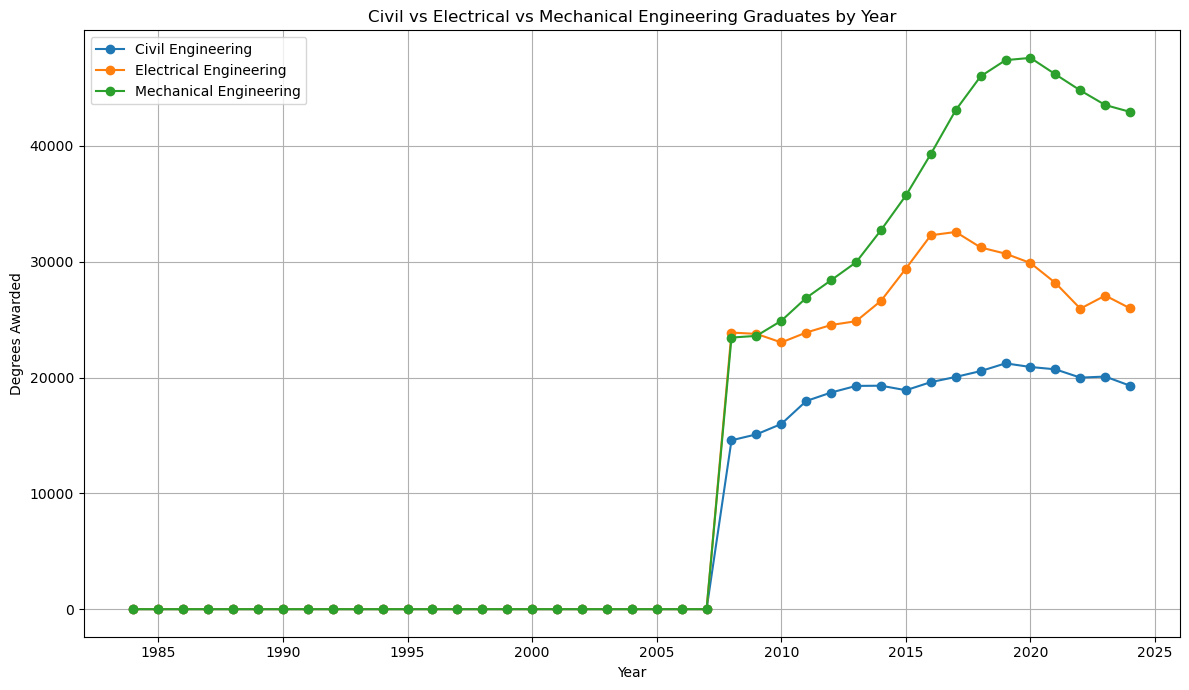

DONE
Total rows read: 8,830,649
Matched rows: 82,175
Total time: 29.8 sec


In [68]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import time

# ==================================================
# READ V6 ONLY — NO NEW FILE CREATED
# ==================================================

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

chunksize = 200_000

usecols = [
    "year",
    "degree_count",
    "cip_code",
    "major_name",
    "degree_group"
]

# Exact CIP codes for the 3 engineering majors
target_cips = {
    "140801": "Civil Engineering",
    "141001": "Electrical Engineering",
    "141901": "Mechanical Engineering"
}

def clean_cip(x):
    x = str(x).strip().replace(".", "")
    x = "".join(ch for ch in x if ch.isdigit())
    return x.zfill(6)[:6]

parts = []
found_names = []
total_rows = 0
matched_rows = 0
start_time = time.time()

print("Finding Civil, Electrical, and Mechanical Engineering...")
print("File:", file)
print("=" * 60)

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize,
        dtype=str,
        keep_default_na=False,
        low_memory=False
    ),
    start=1
):
    total_rows += len(chunk)

    chunk["cip6"] = chunk["cip_code"].apply(clean_cip)

    # Find only the 3 target majors
    match = chunk[chunk["cip6"].isin(target_cips.keys())].copy()

    if not match.empty:
        match["engineering_major"] = match["cip6"].map(target_cips)
        match["degree_count"] = pd.to_numeric(match["degree_count"], errors="coerce").fillna(0)

        found_names.append(
            match[["cip_code", "major_name", "engineering_major"]].drop_duplicates()
        )

        grouped = (
            match.groupby(["year", "engineering_major"], as_index=False)["degree_count"]
            .sum()
        )

        parts.append(grouped)
        matched_rows += len(match)

    print(
        f"Chunk {chunk_num} done | "
        f"Rows read: {total_rows:,} | "
        f"Matched rows: {matched_rows:,} | "
        f"Time: {time.time() - start_time:.1f} sec"
    )

print("=" * 60)

if not parts:
    print("No matching majors found.")
else:
    # Combine in memory only
    result = pd.concat(parts, ignore_index=True)

    final_result = (
        result.groupby(["year", "engineering_major"], as_index=False)["degree_count"]
        .sum()
    )

    final_result["year"] = pd.to_numeric(final_result["year"], errors="coerce")
    final_result = final_result.dropna(subset=["year"])
    final_result["year"] = final_result["year"].astype(int)
    final_result = final_result.sort_values(["year", "engineering_major"])

    found_table = pd.concat(found_names, ignore_index=True).drop_duplicates()

    print("FOUND THESE MAJORS:")
    display(found_table)

    print("CHART DATA PREVIEW:")
    display(final_result.head(20))

    # ==================================================
    # CREATE LINE CHART — NO FILE SAVED
    # ==================================================

    pivot = final_result.pivot_table(
        index="year",
        columns="engineering_major",
        values="degree_count",
        aggfunc="sum",
        fill_value=0
    )

    plt.figure(figsize=(12, 7))

    for major in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[major],
            marker="o",
            label=major
        )

    plt.title("Civil vs Electrical vs Mechanical Engineering Graduates by Year")
    plt.xlabel("Year")
    plt.ylabel("Degrees Awarded")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("=" * 60)
    print("DONE")
    print("Total rows read:", f"{total_rows:,}")
    print("Matched rows:", f"{matched_rows:,}")
    print("Total time:", f"{time.time() - start_time:.1f} sec")

# List by year Test

In [71]:
import pandas as pd
from pathlib import Path
import time

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

chunksize = 200_000

usecols = [
    "year",
    "cip_code",
    "field_group",
    "field_subgroup",
    "major_name"
]

parts = []
total_rows = 0
matched_rows = 0
start_time = time.time()

print("Finding engineering-related majors by year...")
print("File:", file)
print("=" * 60)

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize,
        dtype=str,
        keep_default_na=False,
        low_memory=False
    ),
    start=1
):
    total_rows += len(chunk)

    # Filter engineering-related majors
    mask = (
        chunk["field_group"].str.contains("engineer", case=False, na=False) |
        chunk["field_subgroup"].str.contains("engineer", case=False, na=False) |
        chunk["major_name"].str.contains("engineer", case=False, na=False)
    )

    match = chunk[mask].copy()

    if not match.empty:
        # Keep only year + major name
        match = match[["year", "major_name"]].drop_duplicates()

        parts.append(match)
        matched_rows += len(match)

    print(
        f"Chunk {chunk_num} done | "
        f"Rows read: {total_rows:,} | "
        f"Matched unique year-major rows: {matched_rows:,} | "
        f"Time: {time.time() - start_time:.1f} sec"
    )

print("=" * 60)

if not parts:
    print("No engineering-related majors found.")
else:
    engineering_by_year = pd.concat(parts, ignore_index=True).drop_duplicates()

    engineering_by_year["year"] = pd.to_numeric(
        engineering_by_year["year"],
        errors="coerce"
    )

    engineering_by_year = engineering_by_year.dropna(subset=["year"])
    engineering_by_year["year"] = engineering_by_year["year"].astype(int)

    engineering_by_year = engineering_by_year.sort_values(["year", "major_name"])

    # Make list by year
    year_major_list = (
        engineering_by_year
        .groupby("year")["major_name"]
        .apply(lambda x: sorted(x.unique()))
        .reset_index(name="major_list")
    )

    # Add how many majors each year
    year_major_list["major_count"] = year_major_list["major_list"].apply(len)

    print("DONE")
    print("Total rows read:", f"{total_rows:,}")
    print("Total unique year-major matches:", f"{len(engineering_by_year):,}")
    print("Total time:", f"{time.time() - start_time:.1f} sec")
    print("=" * 60)

    display(year_major_list)

Finding engineering-related majors by year...
File: FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv
Chunk 1 done | Rows read: 200,000 | Matched unique year-major rows: 159 | Time: 0.8 sec
Chunk 2 done | Rows read: 400,000 | Matched unique year-major rows: 458 | Time: 1.6 sec
Chunk 3 done | Rows read: 600,000 | Matched unique year-major rows: 610 | Time: 2.3 sec
Chunk 4 done | Rows read: 800,000 | Matched unique year-major rows: 818 | Time: 3.1 sec
Chunk 5 done | Rows read: 1,000,000 | Matched unique year-major rows: 1,008 | Time: 3.8 sec
Chunk 6 done | Rows read: 1,200,000 | Matched unique year-major rows: 1,153 | Time: 4.5 sec
Chunk 7 done | Rows read: 1,400,000 | Matched unique year-major rows: 1,299 | Time: 5.3 sec
Chunk 8 done | Rows read: 1,600,000 | Matched unique year-major rows: 1,503 | Time: 6.1 sec
Chunk 9 done | Rows read: 1,800,000 | Matched unique year-major rows: 1,648 | Time: 6.9 sec
Chunk 10 done | Rows read: 2,000,000 | Matched unique year-major rows: 1,793 | Time: 7.

,year,major_list,major_count
0,1984,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Agricultural Engineering...",79
1,1985,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Aerospace, Aeronautical,...",150
2,1986,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (1402010000), Agricultural Enginee...",148
3,1987,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Agricultural Engineering...",77
4,1988,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Agricultural Engineering...",77
5,1989,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Agricultural Engineering...",78
6,1990,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Agricultural Engineering...",76
7,1991,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Agricultural Engineering...",77
8,1992,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Agricultural Engineering...",74
9,1993,"[Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201), Agricultural Engineering...",74


# view one year only Test

In [76]:
import pandas as pd
from pathlib import Path
import time

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

chunksize = 200_000

usecols = [
    "year",
    "cip_code",
    "field_group",
    "field_subgroup",
    "major_name"
]

parts = []
total_rows = 0
matched_rows = 0
start_time = time.time()

print("Finding engineering-related majors for 1984 only...")
print("File:", file)
print("=" * 60)

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize,
        dtype=str,
        keep_default_na=False,
        low_memory=False
    ),
    start=1
):
    total_rows += len(chunk)

    # Keep 1984 only
    chunk = chunk[chunk["year"].astype(str).str.strip() == "1984"]

    # Filter engineering-related majors
    mask = (
        chunk["field_group"].str.contains("engineer", case=False, na=False) |
        chunk["field_subgroup"].str.contains("engineer", case=False, na=False) |
        chunk["major_name"].str.contains("engineer", case=False, na=False)
    )

    match = chunk[mask].copy()

    if not match.empty:
        match = match[
            ["year", "cip_code", "field_group", "field_subgroup", "major_name"]
        ].drop_duplicates()

        parts.append(match)
        matched_rows += len(match)

    print(
        f"Chunk {chunk_num} done | "
        f"Rows read: {total_rows:,} | "
        f"Matched rows: {matched_rows:,} | "
        f"Time: {time.time() - start_time:.1f} sec"
    )

print("=" * 60)

if not parts:
    print("No engineering-related majors found for 1984.")
else:
    engineering_1984_table = pd.concat(parts, ignore_index=True).drop_duplicates()

    engineering_1984_table = engineering_1984_table.sort_values(
        ["field_subgroup", "major_name"]
    ).reset_index(drop=True)

    print("DONE")
    print("Engineering-related majors found for 1984:", len(engineering_1984_table))
    print("Total rows read:", f"{total_rows:,}")
    print("Total time:", f"{time.time() - start_time:.1f} sec")
    print("=" * 60)

    display(engineering_1984_table)

Finding engineering-related majors for 1984 only...
File: FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv
Chunk 1 done | Rows read: 200,000 | Matched rows: 79 | Time: 0.9 sec
Chunk 2 done | Rows read: 400,000 | Matched rows: 79 | Time: 1.5 sec
Chunk 3 done | Rows read: 600,000 | Matched rows: 79 | Time: 2.1 sec
Chunk 4 done | Rows read: 800,000 | Matched rows: 79 | Time: 2.6 sec
Chunk 5 done | Rows read: 1,000,000 | Matched rows: 79 | Time: 3.2 sec
Chunk 6 done | Rows read: 1,200,000 | Matched rows: 79 | Time: 3.8 sec
Chunk 7 done | Rows read: 1,400,000 | Matched rows: 79 | Time: 4.3 sec
Chunk 8 done | Rows read: 1,600,000 | Matched rows: 79 | Time: 5.0 sec
Chunk 9 done | Rows read: 1,800,000 | Matched rows: 79 | Time: 5.6 sec
Chunk 10 done | Rows read: 2,000,000 | Matched rows: 79 | Time: 6.2 sec
Chunk 11 done | Rows read: 2,200,000 | Matched rows: 79 | Time: 6.9 sec
Chunk 12 done | Rows read: 2,400,000 | Matched rows: 79 | Time: 7.5 sec
Chunk 13 done | Rows read: 2,600,000 | Matched

,year,cip_code,field_group,field_subgroup,major_name
0,1984,140201,ENGINEERING,"Aerospace, Aeronautical, and Astronautical/Space Engineering","Aerospace, Aeronautical, and Astronautical/Space Engineering - unspecified major (140201)"
1,1984,140301,ENGINEERING,Agricultural Engineering,Agricultural Engineering - unspecified major (140301)
2,1984,140401,ENGINEERING,Architectural Engineering,Architectural Engineering - unspecified major (140401)
3,1984,150101,ENGINEERING/ENGINEERING-RELATED TECHNOLOGIES/TECHNICIANS,Architectural Engineering Technologies/Technicians,Architectural Engineering Technologies/Technicians - unspecified major (150101)
4,1984,150102,ENGINEERING/ENGINEERING-RELATED TECHNOLOGIES/TECHNICIANS,Architectural Engineering Technologies/Technicians,Architectural Engineering Technologies/Technicians - unspecified major (150102)
5,1984,150199,ENGINEERING/ENGINEERING-RELATED TECHNOLOGIES/TECHNICIANS,Architectural Engineering Technologies/Technicians,Architectural Engineering Technologies/Technicians - unspecified major (150199)
6,1984,140501,ENGINEERING,Biomedical/Medical Engineering,Biomedical/Medical Engineering - unspecified major (140501)
7,1984,140601,ENGINEERING,Ceramic Sciences and Engineering,Ceramic Sciences and Engineering - unspecified major (140601)
8,1984,140701,ENGINEERING,Chemical Engineering,Chemical Engineering - unspecified major (140701)
9,1984,140801,ENGINEERING,Civil Engineering,Civil Engineering - unspecified major (140801)


# Test for count in old year for fix, and chart

Using columns:
- year
- cip_code
- cipcode
- CIPCODE
- major_name
- degree_count
- CTOTALT
- crace15
- crace16
- CRACE15
- CRACE16
Reading V6 in chunks...
File: FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv
Chunk 1 done | Rows read: 200,000 | Matched rows: 2,526 | Time: 1.0 sec
Chunk 2 done | Rows read: 400,000 | Matched rows: 5,079 | Time: 2.0 sec
Chunk 3 done | Rows read: 600,000 | Matched rows: 7,542 | Time: 2.9 sec
Chunk 4 done | Rows read: 800,000 | Matched rows: 9,989 | Time: 3.8 sec
Chunk 5 done | Rows read: 1,000,000 | Matched rows: 12,492 | Time: 4.8 sec
Chunk 6 done | Rows read: 1,200,000 | Matched rows: 14,943 | Time: 5.7 sec
Chunk 7 done | Rows read: 1,400,000 | Matched rows: 17,359 | Time: 6.6 sec
Chunk 8 done | Rows read: 1,600,000 | Matched rows: 19,529 | Time: 7.5 sec
Chunk 9 done | Rows read: 1,800,000 | Matched rows: 21,582 | Time: 8.5 sec
Chunk 10 done | Rows read: 2,000,000 | Matched rows: 23,461 | Time: 9.4 sec
Chunk 11 done | Rows read: 2,200,000 | Matched rows

,year,engineering_major,fixed_degree_count
0,1984,Civil Engineering,13361
1,1984,Electrical Engineering,26921
2,1984,Mechanical Engineering,19904
3,1985,Civil Engineering,12849
4,1985,Electrical Engineering,28746
5,1985,Mechanical Engineering,20401
6,1986,Civil Engineering,12157
7,1986,Electrical Engineering,32489
8,1986,Mechanical Engineering,19900
9,1987,Civil Engineering,11623


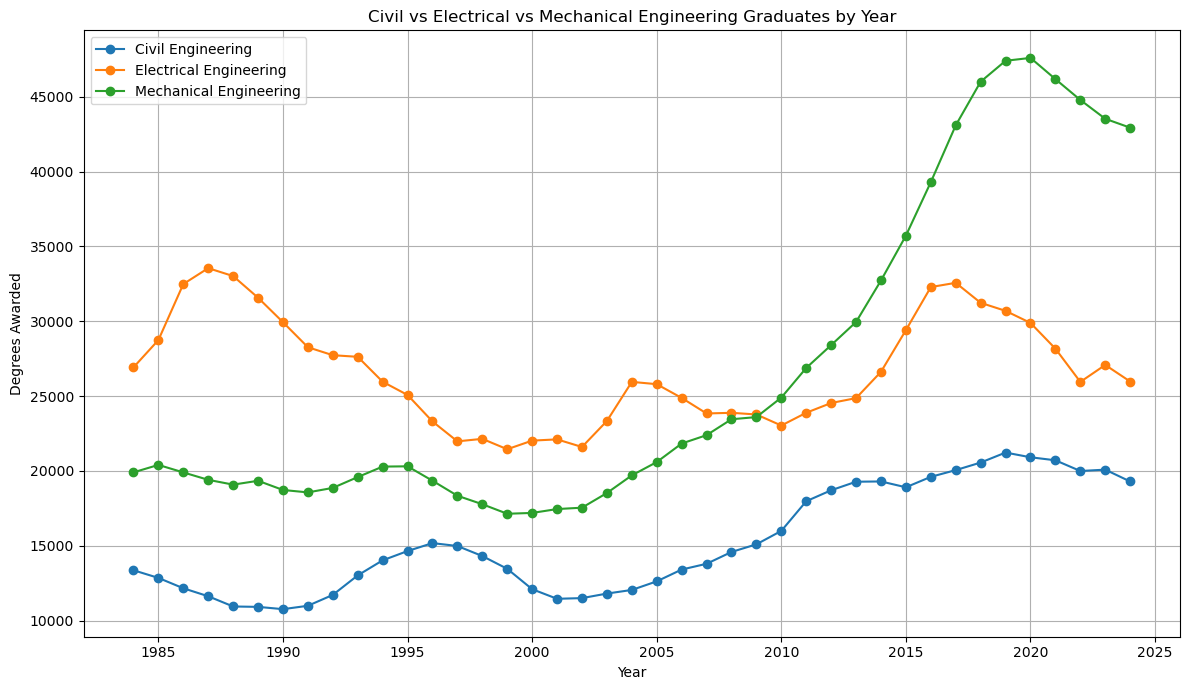

DONE
Total rows read: 8,830,649
Matched rows: 82,175
Total time: 43.8 sec


In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import time

# ==================================================
# FILE
# ==================================================

file = Path("FileVersion/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv")

chunksize = 200_000

# ==================================================
# READ HEADER ONLY
# ==================================================

all_columns = pd.read_csv(file, nrows=0).columns.tolist()

wanted_cols = [
    "year",
    "cip_code", "cipcode", "CIPCODE",
    "major_name",
    "degree_count",
    "CTOTALT",
    "crace15", "crace16",
    "CRACE15", "CRACE16"
]

usecols = [c for c in wanted_cols if c in all_columns]

print("Using columns:")
for c in usecols:
    print("-", c)

print("=" * 60)

# ==================================================
# TARGET MAJORS
# ==================================================

target_cips = {
    "140801": "Civil Engineering",
    "141001": "Electrical Engineering",
    "141901": "Mechanical Engineering"
}

def clean_cip(x):
    x = str(x).strip().replace(".", "")
    x = "".join(ch for ch in x if ch.isdigit())
    return x.zfill(6)[:6]

# ==================================================
# READ IN CHUNKS — MEMORY OPTIMIZED
# ==================================================

parts = []
total_rows = 0
matched_rows = 0
start_time = time.time()

print("Reading V6 in chunks...")
print("File:", file)
print("=" * 60)

for chunk_num, chunk in enumerate(
    pd.read_csv(
        file,
        usecols=usecols,
        chunksize=chunksize,
        dtype=str,
        keep_default_na=False,
        low_memory=False
    ),
    start=1
):
    total_rows += len(chunk)

    # Pick CIP from whichever CIP column has data
    chunk["cip_source"] = ""

    for c in ["cip_code", "cipcode", "CIPCODE"]:
        if c in chunk.columns:
            mask = chunk["cip_source"].eq("") & chunk[c].astype(str).str.strip().ne("")
            chunk.loc[mask, "cip_source"] = chunk.loc[mask, c]

    chunk["cip6"] = chunk["cip_source"].apply(clean_cip)

    # Keep only Civil, Electrical, Mechanical
    match = chunk[chunk["cip6"].isin(target_cips.keys())].copy()

    if not match.empty:
        match["engineering_major"] = match["cip6"].map(target_cips)

        # Convert count columns to numbers
        for c in ["degree_count", "CTOTALT", "crace15", "crace16", "CRACE15", "CRACE16"]:
            if c in match.columns:
                match[c] = pd.to_numeric(match[c], errors="coerce").fillna(0)

        # Create fixed count
        match["fixed_degree_count"] = 0

        # Newer years
        if "degree_count" in match.columns:
            match["fixed_degree_count"] = match["degree_count"]

        # Some years use CTOTALT
        if "CTOTALT" in match.columns:
            match.loc[
                match["fixed_degree_count"].eq(0),
                "fixed_degree_count"
            ] = match["CTOTALT"]

        # Older years may use crace15 + crace16
        if "crace15" in match.columns and "crace16" in match.columns:
            old_total = match["crace15"] + match["crace16"]
            match.loc[
                match["fixed_degree_count"].eq(0),
                "fixed_degree_count"
            ] = old_total

        # Older uppercase version
        if "CRACE15" in match.columns and "CRACE16" in match.columns:
            old_total_upper = match["CRACE15"] + match["CRACE16"]
            match.loc[
                match["fixed_degree_count"].eq(0),
                "fixed_degree_count"
            ] = old_total_upper

        grouped = (
            match.groupby(["year", "engineering_major"], as_index=False)["fixed_degree_count"]
            .sum()
        )

        parts.append(grouped)
        matched_rows += len(match)

    elapsed = time.time() - start_time

    print(
        f"Chunk {chunk_num} done | "
        f"Rows read: {total_rows:,} | "
        f"Matched rows: {matched_rows:,} | "
        f"Time: {elapsed:.1f} sec"
    )

print("=" * 60)

# ==================================================
# COMBINE + CHART
# ==================================================

if not parts:
    print("No matching engineering majors found.")
else:
    final_result = pd.concat(parts, ignore_index=True)

    final_result = (
        final_result.groupby(["year", "engineering_major"], as_index=False)["fixed_degree_count"]
        .sum()
    )

    final_result["year"] = pd.to_numeric(final_result["year"], errors="coerce")
    final_result = final_result.dropna(subset=["year"])
    final_result["year"] = final_result["year"].astype(int)

    final_result = final_result.sort_values(["year", "engineering_major"])

    print("Chart data preview:")
    display(final_result.head(30))

    pivot = final_result.pivot_table(
        index="year",
        columns="engineering_major",
        values="fixed_degree_count",
        aggfunc="sum",
        fill_value=0
    )

    plt.figure(figsize=(12, 7))

    for major in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[major],
            marker="o",
            label=major
        )

    plt.title("Civil vs Electrical vs Mechanical Engineering Graduates by Year")
    plt.xlabel("Year")
    plt.ylabel("Degrees Awarded")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("=" * 60)
    print("DONE")
    print("Total rows read:", f"{total_rows:,}")
    print("Matched rows:", f"{matched_rows:,}")
    print("Total time:", f"{time.time() - start_time:.1f} sec")

In [ ]:
import pandas as pd
from pathlib import Path

# Change this to your file
file_path = Path.home() / "Downloads/Internship_SCIPE CI-SIP/MainProject/1_Degree/TestFinish/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv"

# Check file exists
if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

print("Reading only top 25 rows...")
print(f"File: {file_path}")

# Memory optimization: only read first 25 rows
df_top25 = pd.read_csv(
    file_path,
    nrows=25,
    low_memory=False
)

print("\nDONE")
print("Rows loaded:", len(df_top25))
print("Columns found:", len(df_top25.columns))

# Show all column names
print("\nALL COLUMNS:")
for i, col in enumerate(df_top25.columns, start=1):
    print(f"{i}. {col}")

# Display all columns in table
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 100)

print("\nTOP 25 ROWS:")
display(df_top25)

In [ ]:
pwd

In [ ]:
import pandas as pd
from pathlib import Path

file_path = Path.home() / "Downloads/Internship_SCIPE CI-SIP/MainProject/1_Degree/TestFinish/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv"

print(file_path)

if not file_path.exists():
    raise FileNotFoundError(f"File not found: {file_path}")

df_top25 = pd.read_csv(
    file_path,
    nrows=25,
    low_memory=False
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 150)

display(df_top25)

In [25]:
import pandas as pd
from pathlib import Path

file_path = Path.home() / "Downloads/Internship_SCIPE CI-SIP/MainProject/1_Degree/TestFinish/IPEDS_ALL_ORIGINAL_INFO_FIXED_V6.csv"

keep_cols = [
    "year",
    "unitid",
    "cip_code",
    "award_level_code",
    "award_level_name",
    "degree_group",
    "degree_count",
    "field_group",
    "field_subgroup",
    "major_name"
]

# Read only header first, not full file
all_cols = pd.read_csv(file_path, nrows=0).columns.tolist()

# Keep only columns that exist
use_cols = [c for c in keep_cols if c in all_cols]

df_top25 = pd.read_csv(
    file_path,
    usecols=use_cols,
    nrows=25,
    low_memory=False
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 150)

display(df_top25)

,unitid,year,award_level_code,award_level_name,degree_group,cip_code,degree_count,field_group,field_subgroup,major_name
0,100654,1984,5,Bachelor,Bachelor,10102,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10102),Unmapped / Nonstandard CIP Major (100102)
1,100654,1984,7,Master,Master,10102,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10102),Unmapped / Nonstandard CIP Major (100102)
2,100654,1984,5,Bachelor,Bachelor,10103,0,COMMUNICATIONS TECHNOLOGIES/TECHNICIANS AND SUPPORT SERVICES,Unmapped / Nonstandard CIP Subgroup (10103),Unmapped / Nonstandard CIP Major (100103)
3,100654,1984,5,Bachelor,Bachelor,20201,0,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20201),Unmapped / Nonstandard CIP Major (200201)
4,100654,1984,5,Bachelor,Bachelor,20301,0,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20301),Unmapped / Nonstandard CIP Major (200301)
5,100654,1984,7,Master,Master,20399,0,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20399),Unmapped / Nonstandard CIP Major (200399)
6,100654,1984,5,Bachelor,Bachelor,20501,0,Unmapped / Nonstandard CIP Field (20),Unmapped / Nonstandard CIP Subgroup (20501),Unmapped / Nonstandard CIP Major (200501)
7,100654,1984,5,Bachelor,Bachelor,29999,0,MILITARY TECHNOLOGIES AND APPLIED SCIENCES,Unmapped / Nonstandard CIP Subgroup (29999),Unmapped / Nonstandard CIP Major (290999)
8,100654,1984,7,Master,Master,29999,0,MILITARY TECHNOLOGIES AND APPLIED SCIENCES,Unmapped / Nonstandard CIP Subgroup (29999),Unmapped / Nonstandard CIP Major (290999)
9,100654,1984,5,Bachelor,Bachelor,30499,0,MULTI/INTERDISCIPLINARY STUDIES,Unmapped / Nonstandard CIP Subgroup (30499),Unmapped / Nonstandard CIP Major (300499)
